# Hierarchical Agglomerative Clustering Analysis

## Objective
Apply Hierarchical Agglomerative Clustering (HAC) to student performance data across three academic years to identify natural groupings based on student characteristics and performance metrics.

## Methodology
1. Data Preparation and Feature Selection
2. Feature Scaling using StandardScaler
3. Dendrogram Analysis for optimal cluster selection
4. Agglomerative Clustering Application with multiple linkage methods
5. Evaluation using internal validation metrics
6. Suitability Assessment for each year's data

In [55]:
# =============================================================================
# Import Required Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Scikit-learn imports for clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")

All libraries imported successfully.


In [56]:
# =============================================================================
# Load Data
# =============================================================================
data_1y = pd.read_csv('../data/1y_final_clean_encoded.csv')
data_2y = pd.read_csv('../data/2y_final_clean_encoded.csv')
data_3y = pd.read_csv('../data/3y_final_clean_encoded.csv')

print("=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"\n{'Dataset':<15} {'Rows':<10} {'Columns':<10}")
print("-" * 35)
print(f"{'1st Year':<15} {data_1y.shape[0]:<10} {data_1y.shape[1]:<10}")
print(f"{'2nd Year':<15} {data_2y.shape[0]:<10} {data_2y.shape[1]:<10}")
print(f"{'3rd Year':<15} {data_3y.shape[0]:<10} {data_3y.shape[1]:<10}")
print("\nData loaded successfully.")

data_1y.head()

DATA LOADING SUMMARY

Dataset         Rows       Columns   
-----------------------------------
1st Year        210        57        
2nd Year        101        64        
3rd Year        12         49        

Data loaded successfully.


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y english 2,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat
0,1,1,2,2,0,0,0,22,16,0,...,2,0,0,0,1,0,1,0,0,1
1,2,0,2,0,1,2,0,54,36,1,...,2,0,0,0,1,0,1,0,0,1
2,3,0,2,2,0,3,0,14,31,1,...,2,0,0,0,1,0,1,0,0,1
3,4,1,2,0,0,2,2,54,34,0,...,0,0,0,0,1,0,1,0,0,1
4,5,1,2,1,0,2,0,54,34,0,...,0,0,0,0,1,0,1,0,0,1


## 1. Data Exploration

In [57]:
# =============================================================================
# Explore Data Structure
# =============================================================================

def explore_dataset(df, name):
    """Dataset exploration function."""
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"\nNumeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")
    
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values detected:")
        print(missing[missing > 0])
    else:
        print(f"\nNo missing values")
    
    print(f"\nStatistical Summary:")
    display(df.describe().round(2))
    
    return numeric_cols, categorical_cols

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

numeric_1y, categorical_1y = explore_dataset(data_1y, "1st Year Students")
numeric_2y, categorical_2y = explore_dataset(data_2y, "2nd Year Students")
numeric_3y, categorical_3y = explore_dataset(data_3y, "3rd Year Students")


DATA EXPLORATION

DATASET: 1st Year Students

Shape: 210 rows x 57 columns

Numeric columns: 57
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y english 2,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,...,210.00,210.00,210.00,210.00,210.00,210.00,210.0,210.00,210.00,210.00
mean,105.50,0.45,2.06,0.58,1.17,2.20,0.28,25.80,20.15,0.38,...,1.12,0.96,0.42,0.47,0.55,0.80,1.1,1.05,1.06,1.22
std,60.77,0.50,0.54,0.66,1.31,1.07,0.56,17.08,11.91,0.49,...,1.36,1.00,0.80,0.50,0.73,1.08,1.2,0.94,0.97,1.14
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,53.25,0.00,2.00,0.00,0.00,2.00,0.00,11.00,10.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,105.50,0.00,2.00,0.00,1.00,3.00,0.00,24.50,19.50,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.5,1.00,2.00,1.00
75%,157.75,1.00,2.00,1.00,2.00,3.00,0.00,40.00,31.00,1.00,...,2.00,2.00,0.00,1.00,1.00,2.00,2.0,2.00,2.00,2.00
max,210.00,1.00,3.00,2.00,5.00,3.00,2.00,57.00,40.00,1.00,...,4.00,2.00,2.00,1.00,2.00,3.00,3.0,2.00,2.00,4.00



DATASET: 2nd Year Students

Shape: 101 rows x 64 columns

Numeric columns: 64
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,2y complexity,2y proba stat ii,2y lin alg ii,2y intro ai,2y oper res,2y archi ii,2y oper syst,2y soft eng,2y web prog,2y intro busin
count,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,...,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,238.80,0.43,1.67,0.50,0.80,1.42,0.32,22.56,17.08,0.35,...,0.82,0.85,1.57,1.19,1.14,1.47,1.40,0.66,1.48,0.10
std,139.72,0.50,0.68,0.74,1.16,0.77,0.58,15.55,9.81,0.48,...,0.48,0.38,0.82,0.50,0.66,0.90,1.01,0.52,0.88,0.41
min,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,119.00,0.00,2.00,0.00,0.00,1.00,0.00,7.00,8.00,0.00,...,1.00,1.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,210.00,0.00,2.00,0.00,0.00,2.00,0.00,23.00,20.00,0.00,...,1.00,1.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,0.00
75%,364.00,1.00,2.00,1.00,1.00,2.00,1.00,36.00,25.00,1.00,...,1.00,1.00,2.00,1.00,2.00,2.00,2.00,1.00,2.00,0.00
max,475.00,1.00,2.00,2.00,5.00,2.00,2.00,49.00,32.00,1.00,...,2.00,2.00,2.00,2.00,2.00,3.00,3.00,2.00,2.00,2.00



DATASET: 3rd Year Students

Shape: 12 rows x 49 columns

Numeric columns: 49
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,3y stochastic,3y software engineering,3y networks and protocols,3y mobile development,3y entrepreneurship and innovation,3y machine learning,3y numerical methods and optimisation,3y time series,3y advanced databases,3y computer and network security
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,...,12.00,12.00,12.0,12.00,12.00,12.0,12.00,12.00,12.00,12.00
mean,119.58,0.33,0.08,0.42,0.58,1.58,0.17,5.33,4.17,0.58,...,0.92,0.25,1.0,0.25,0.17,0.0,0.75,0.75,0.67,0.33
std,49.28,0.49,0.29,0.51,0.79,0.79,0.39,3.37,2.79,0.51,...,0.29,0.45,0.6,0.45,0.39,0.0,0.97,1.06,0.49,0.49
min,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,83.00,0.00,0.00,0.00,0.00,1.75,0.00,2.75,1.75,0.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
50%,112.50,0.00,0.00,0.00,0.00,2.00,0.00,5.50,4.50,1.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,1.00,0.00
75%,147.25,1.00,0.00,1.00,1.00,2.00,0.00,8.25,6.25,1.00,...,1.00,0.25,1.0,0.25,0.00,0.0,2.00,1.25,1.00,1.00
max,210.00,1.00,1.00,1.00,2.00,2.00,1.00,10.00,8.00,1.00,...,1.00,1.00,2.0,1.00,1.00,0.0,2.00,3.00,1.00,1.00


In [58]:
# =============================================================================
# Feature Selection for Clustering
# =============================================================================

# Define feature categories
demographic_features = ['gender', 'bac_specialty']

study_habit_features = ['study_hours_per_week', 'preferred_study_place', 'preferred_study_time',
                        'learning_methods', 'study_resources', 'uses_planner']

self_assessment_features = ['english_level', 'programming_level', 'computer_science_level', 
                            'mathematics_level']

wellbeing_features = ['motivation_level', 'sleep_hours', 'stress_management', 
                      'program_satisfaction', 'external_activities']

# Common features for clustering
common_features = demographic_features + study_habit_features + self_assessment_features + wellbeing_features

print("="*60)
print("FEATURE SELECTION FOR CLUSTERING")
print("="*60)
print(f"\nSelected {len(common_features)} common features across all years:")
print(f"\n1. Demographic Features ({len(demographic_features)}):")
for f in demographic_features:
    print(f"   - {f}")
print(f"\n2. Study Habit Features ({len(study_habit_features)}):")
for f in study_habit_features:
    print(f"   - {f}")
print(f"\n3. Self-Assessment Features ({len(self_assessment_features)}):")
for f in self_assessment_features:
    print(f"   - {f}")
print(f"\n4. Wellbeing Features ({len(wellbeing_features)}):")
for f in wellbeing_features:
    print(f"   - {f}")

# Verify features exist
for name, df in [('1st Year', data_1y), ('2nd Year', data_2y), ('3rd Year', data_3y)]:
    missing_features = [f for f in common_features if f not in df.columns]
    if missing_features:
        print(f"\n{name} missing features: {missing_features}")
    else:
        print(f"\n{name}: All common features present")

FEATURE SELECTION FOR CLUSTERING

Selected 17 common features across all years:

1. Demographic Features (2):
   - gender
   - bac_specialty

2. Study Habit Features (6):
   - study_hours_per_week
   - preferred_study_place
   - preferred_study_time
   - learning_methods
   - study_resources
   - uses_planner

3. Self-Assessment Features (4):
   - english_level
   - programming_level
   - computer_science_level
   - mathematics_level

4. Wellbeing Features (5):
   - motivation_level
   - sleep_hours
   - stress_management
   - program_satisfaction
   - external_activities

1st Year: All common features present

2nd Year: All common features present

3rd Year: All common features present


## 2. Data Preparation

In [59]:
# =============================================================================
# Prepare Data for Clustering
# =============================================================================

def prepare_clustering_data(df, features, dataset_name):
    """
    Prepare data for clustering:
    1. Select relevant features
    2. Handle missing values
    3. Standardize features
    """
    print(f"\n{'='*60}")
    print(f"PREPARING: {dataset_name}")
    print(f"{'='*60}")
    
    X = df[features].copy()
    print(f"\nSelected {len(features)} features")
    
    if X.isnull().sum().sum() > 0:
        print(f"Handling {X.isnull().sum().sum()} missing values with median imputation")
        X = X.fillna(X.median())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"Features standardized (mean=0, std=1)")
    print(f"Scaled data shape: {X_scaled.shape}")
    
    return X, X_scaled, scaler

# Prepare all datasets
X_1y, X_1y_scaled, scaler_1y = prepare_clustering_data(data_1y, common_features, "1st Year")
X_2y, X_2y_scaled, scaler_2y = prepare_clustering_data(data_2y, common_features, "2nd Year")
X_3y, X_3y_scaled, scaler_3y = prepare_clustering_data(data_3y, common_features, "3rd Year")

print("\n" + "="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"\n{'Dataset':<15} {'Samples':<12} {'Features':<12}")
print("-" * 39)
print(f"{'1st Year':<15} {X_1y_scaled.shape[0]:<12} {X_1y_scaled.shape[1]:<12}")
print(f"{'2nd Year':<15} {X_2y_scaled.shape[0]:<12} {X_2y_scaled.shape[1]:<12}")
print(f"{'3rd Year':<15} {X_3y_scaled.shape[0]:<12} {X_3y_scaled.shape[1]:<12}")


PREPARING: 1st Year

Selected 17 features
Features standardized (mean=0, std=1)
Scaled data shape: (210, 17)

PREPARING: 2nd Year

Selected 17 features
Features standardized (mean=0, std=1)
Scaled data shape: (101, 17)

PREPARING: 3rd Year

Selected 17 features
Features standardized (mean=0, std=1)
Scaled data shape: (12, 17)

DATA PREPARATION SUMMARY

Dataset         Samples      Features    
---------------------------------------
1st Year        210          17          
2nd Year        101          17          
3rd Year        12           17          


## 2.1 Data Distribution Before Clustering

Visualize the data structure and pairwise distances to understand the inherent data shape before applying Hierarchical Agglomerative Clustering.

In [60]:
# =============================================================================
# Pairwise Distance Analysis
# =============================================================================

def analyze_pairwise_distances(X_scaled, dataset_name):
    """
    Compute and visualize pairwise distance distribution.
    """
    # Calculate pairwise Euclidean distances
    distances = pdist(X_scaled, metric='euclidean')
    
    print(f"\n{'='*60}")
    print(f"PAIRWISE DISTANCE ANALYSIS: {dataset_name}")
    print(f"{'='*60}")
    print(f"\nNumber of pairwise distances: {len(distances)}")
    print(f"\nDistance Statistics:")
    print(f"   Min:    {distances.min():.3f}")
    print(f"   Max:    {distances.max():.3f}")
    print(f"   Mean:   {distances.mean():.3f}")
    print(f"   Std:    {distances.std():.3f}")
    print(f"   Median: {np.median(distances):.3f}")
    
    return distances

# Analyze pairwise distances for all datasets
dist_1y = analyze_pairwise_distances(X_1y_scaled, "1st Year Students")
dist_2y = analyze_pairwise_distances(X_2y_scaled, "2nd Year Students")
dist_3y = analyze_pairwise_distances(X_3y_scaled, "3rd Year Students")


PAIRWISE DISTANCE ANALYSIS: 1st Year Students

Number of pairwise distances: 21945

Distance Statistics:
   Min:    1.541
   Max:    10.189
   Mean:   5.740
   Std:    1.104
   Median: 5.686

PAIRWISE DISTANCE ANALYSIS: 2nd Year Students

Number of pairwise distances: 5050

Distance Statistics:
   Min:    1.734
   Max:    10.844
   Mean:   5.749
   Std:    1.133
   Median: 5.690

PAIRWISE DISTANCE ANALYSIS: 3rd Year Students

Number of pairwise distances: 66

Distance Statistics:
   Min:    3.752
   Max:    8.419
   Mean:   6.013
   Std:    0.965
   Median: 6.043


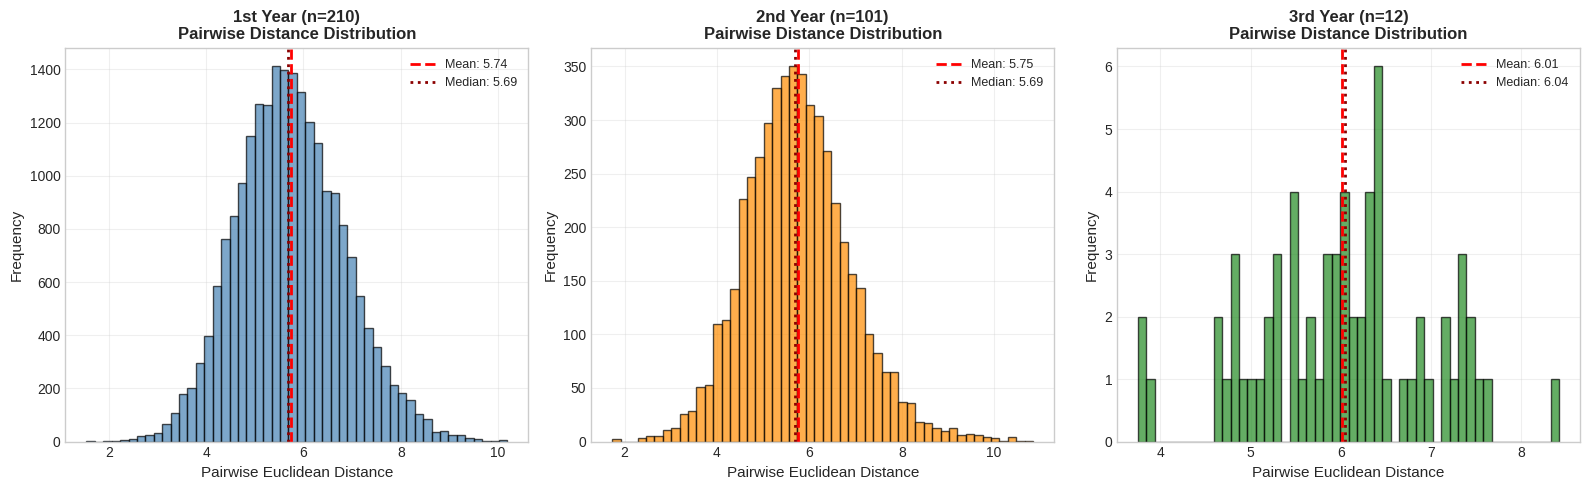


Interpretation:
   - Distance distributions inform linkage method behavior
   - Ward linkage minimizes variance; Complete uses maximum distances
   - Average linkage uses mean of pairwise distances between clusters


In [61]:
# =============================================================================
# Visualize Pairwise Distance Distributions
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, distances, name, color in zip(
    axes, 
    [dist_1y, dist_2y, dist_3y], 
    ['1st Year (n=210)', '2nd Year (n=101)', '3rd Year (n=12)'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    ax.hist(distances, bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(distances), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(distances):.2f}')
    ax.axvline(np.median(distances), color='darkred', linestyle=':', linewidth=2, label=f'Median: {np.median(distances):.2f}')
    ax.set_xlabel('Pairwise Euclidean Distance', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\nPairwise Distance Distribution', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("   - Distance distributions inform linkage method behavior")
print("   - Ward linkage minimizes variance; Complete uses maximum distances")
print("   - Average linkage uses mean of pairwise distances between clusters")

In [62]:
# =============================================================================
# Data Shape Visualization Using PCA (Before Clustering)
# =============================================================================

def visualize_data_before_clustering(X_scaled, dataset_name, n_samples):
    """
    Visualize data distribution using PCA before any clustering is applied.
    """
    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot of all data points
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', s=50, alpha=0.6, 
                   edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[0].set_title(f'{dataset_name} (n={n_samples})\nData Distribution Before Clustering', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Density plot using hexbin
    hb = axes[1].hexbin(X_pca[:, 0], X_pca[:, 1], gridsize=15, cmap='Blues', mincnt=1)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[1].set_title(f'{dataset_name}\nDensity Distribution (Hexbin)', fontsize=12, fontweight='bold')
    plt.colorbar(hb, ax=axes[1], label='Count')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPCA Explained Variance:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"   Total (2 components): {sum(pca.explained_variance_ratio_)*100:.1f}%")
    
    return X_pca, pca

print("\n" + "="*80)
print("DATA SHAPE VISUALIZATION (BEFORE CLUSTERING)")
print("="*80)


DATA SHAPE VISUALIZATION (BEFORE CLUSTERING)



------------------------------------------------------------
1ST YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


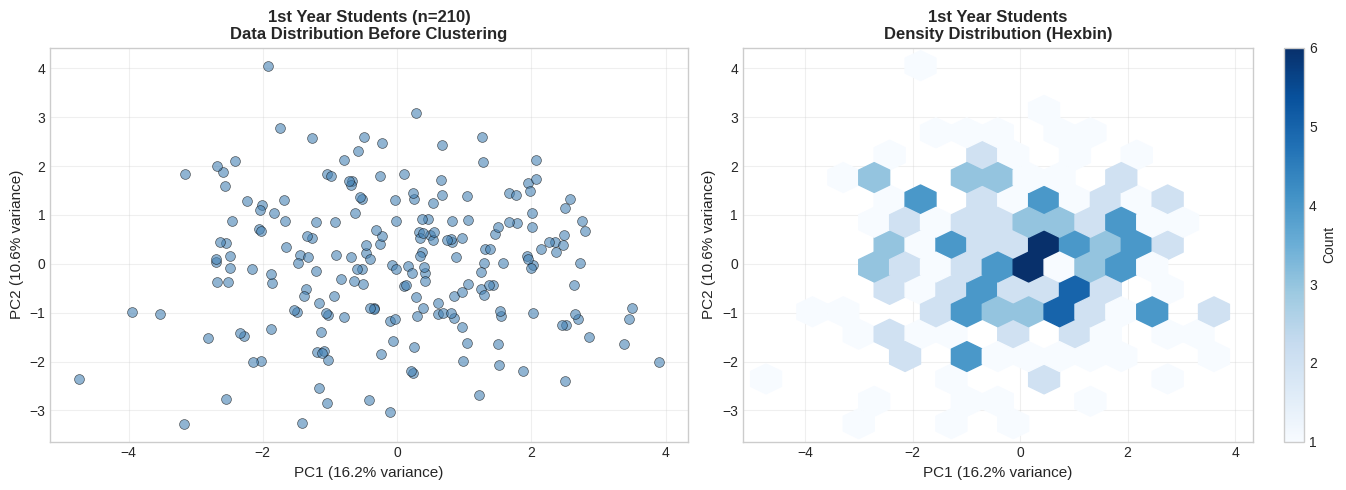


PCA Explained Variance:
   PC1: 16.2%
   PC2: 10.6%
   Total (2 components): 26.8%


In [63]:
# 1st Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("1ST YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_1y_pre, pca_1y_pre = visualize_data_before_clustering(X_1y_scaled, "1st Year Students", len(data_1y))


------------------------------------------------------------
2ND YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


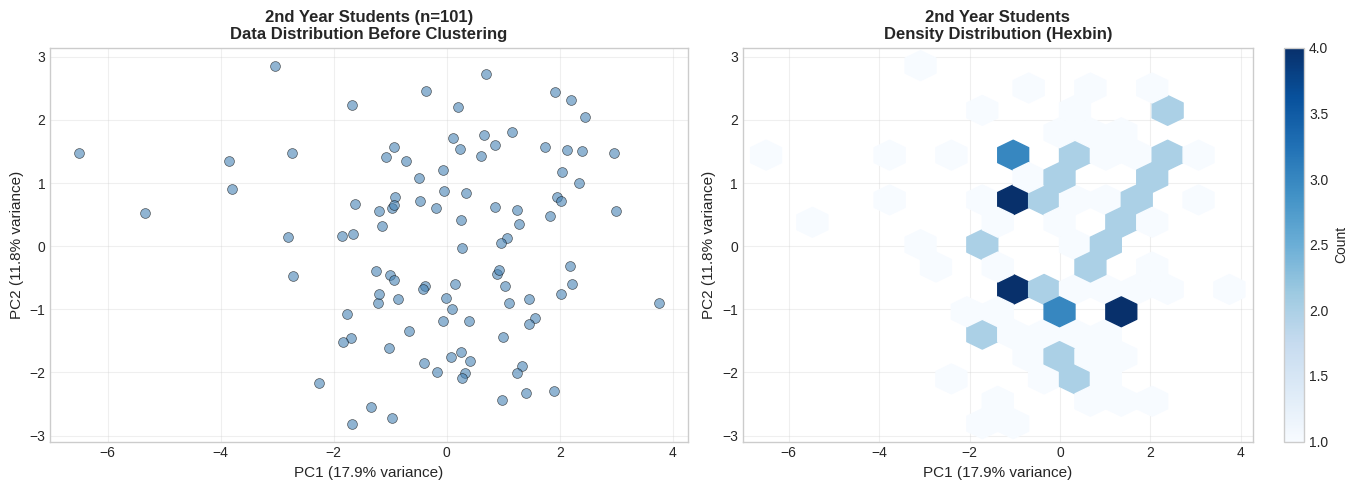


PCA Explained Variance:
   PC1: 17.9%
   PC2: 11.8%
   Total (2 components): 29.7%


In [64]:
# 2nd Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("2ND YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_2y_pre, pca_2y_pre = visualize_data_before_clustering(X_2y_scaled, "2nd Year Students", len(data_2y))


------------------------------------------------------------
3RD YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


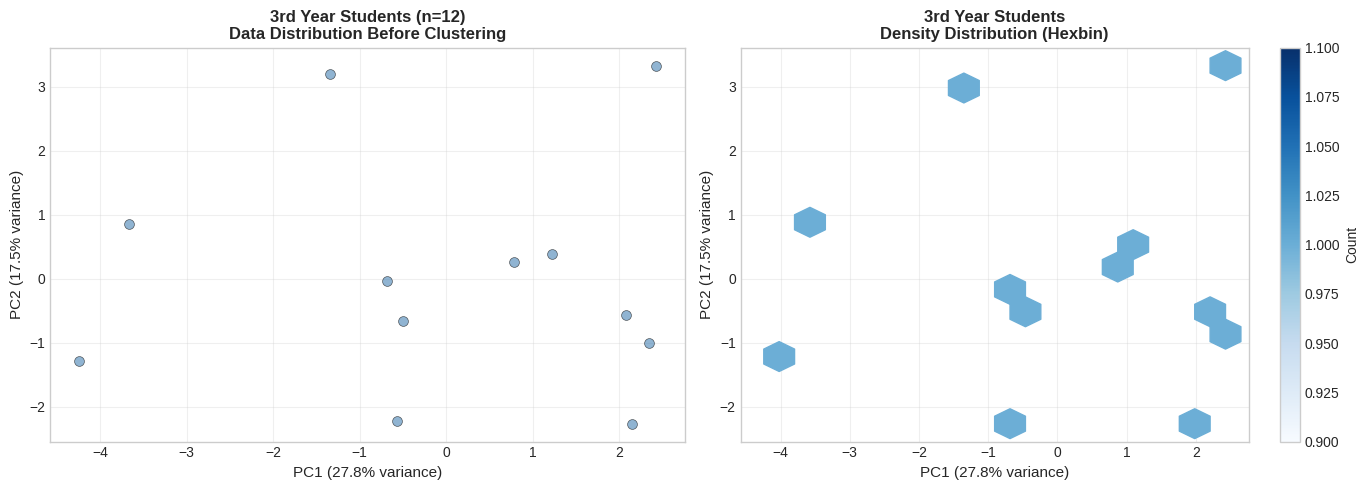


PCA Explained Variance:
   PC1: 27.8%
   PC2: 17.5%
   Total (2 components): 45.4%


In [65]:
# 3rd Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("3RD YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_3y_pre, pca_3y_pre = visualize_data_before_clustering(X_3y_scaled, "3rd Year Students", len(data_3y))

## 3. Dendrogram Analysis for Optimal Cluster Selection

In [66]:
# =============================================================================
# Dendrogram Analysis
# =============================================================================

def plot_dendrogram(X_scaled, dataset_name, linkage_methods=['ward', 'complete', 'average']):
    """
    Plot dendrograms using different linkage methods to determine optimal number of clusters.
    """
    fig, axes = plt.subplots(1, len(linkage_methods), figsize=(6*len(linkage_methods), 6))
    
    if len(linkage_methods) == 1:
        axes = [axes]
    
    linkage_results = {}
    
    for ax, method in zip(axes, linkage_methods):
        # Compute linkage matrix
        Z = linkage(X_scaled, method=method)
        linkage_results[method] = Z
        
        # Plot dendrogram
        dendrogram(Z, ax=ax, truncate_mode='level', p=5, 
                   leaf_rotation=90, leaf_font_size=8,
                   color_threshold=0.7*max(Z[:,2]))
        
        ax.set_title(f'{dataset_name}\nLinkage: {method.capitalize()}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Sample Index or Cluster Size', fontsize=10)
        ax.set_ylabel('Distance', fontsize=10)
        ax.axhline(y=0.7*max(Z[:,2]), color='r', linestyle='--', alpha=0.7, label='Cut threshold')
        ax.legend(loc='best', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return linkage_results

print("\n" + "="*80)
print("DENDROGRAM ANALYSIS")
print("="*80)


DENDROGRAM ANALYSIS



------------------------------------------------------------
1ST YEAR STUDENTS - DENDROGRAM
------------------------------------------------------------


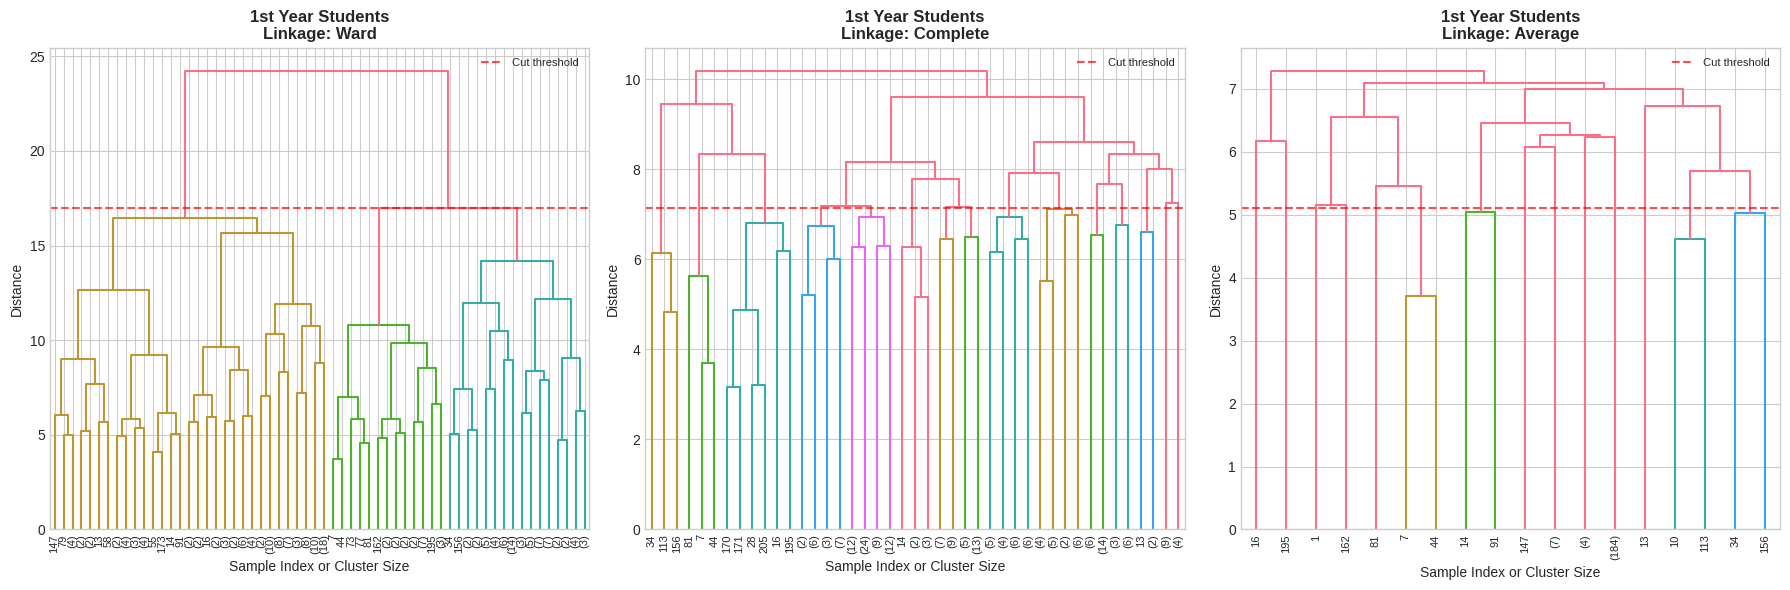

In [67]:
# 1st Year Dendrogram Analysis
print("\n" + "-"*60)
print("1ST YEAR STUDENTS - DENDROGRAM")
print("-"*60)
linkage_1y = plot_dendrogram(X_1y_scaled, "1st Year Students")


------------------------------------------------------------
2ND YEAR STUDENTS - DENDROGRAM
------------------------------------------------------------


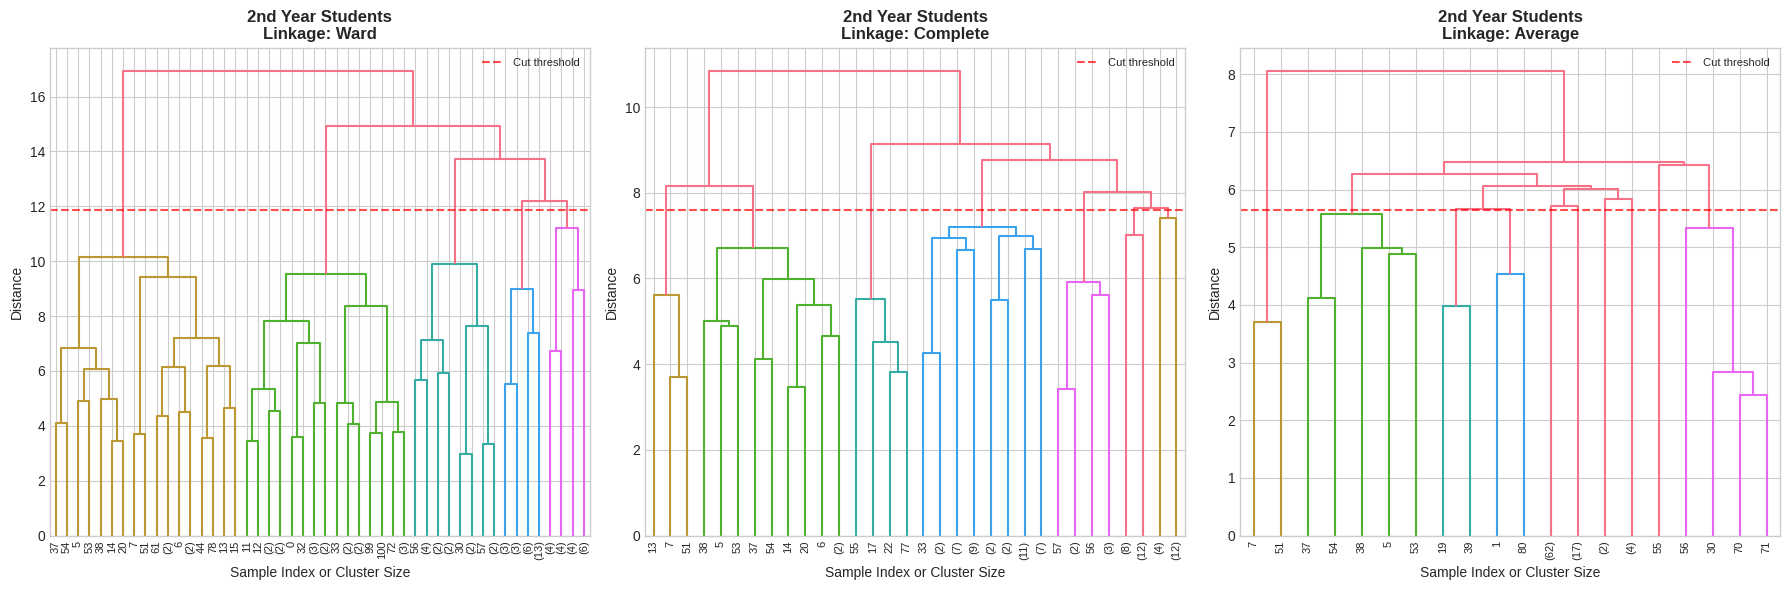

In [68]:
# 2nd Year Dendrogram Analysis
print("\n" + "-"*60)
print("2ND YEAR STUDENTS - DENDROGRAM")
print("-"*60)
linkage_2y = plot_dendrogram(X_2y_scaled, "2nd Year Students")


------------------------------------------------------------
3RD YEAR STUDENTS - DENDROGRAM
------------------------------------------------------------


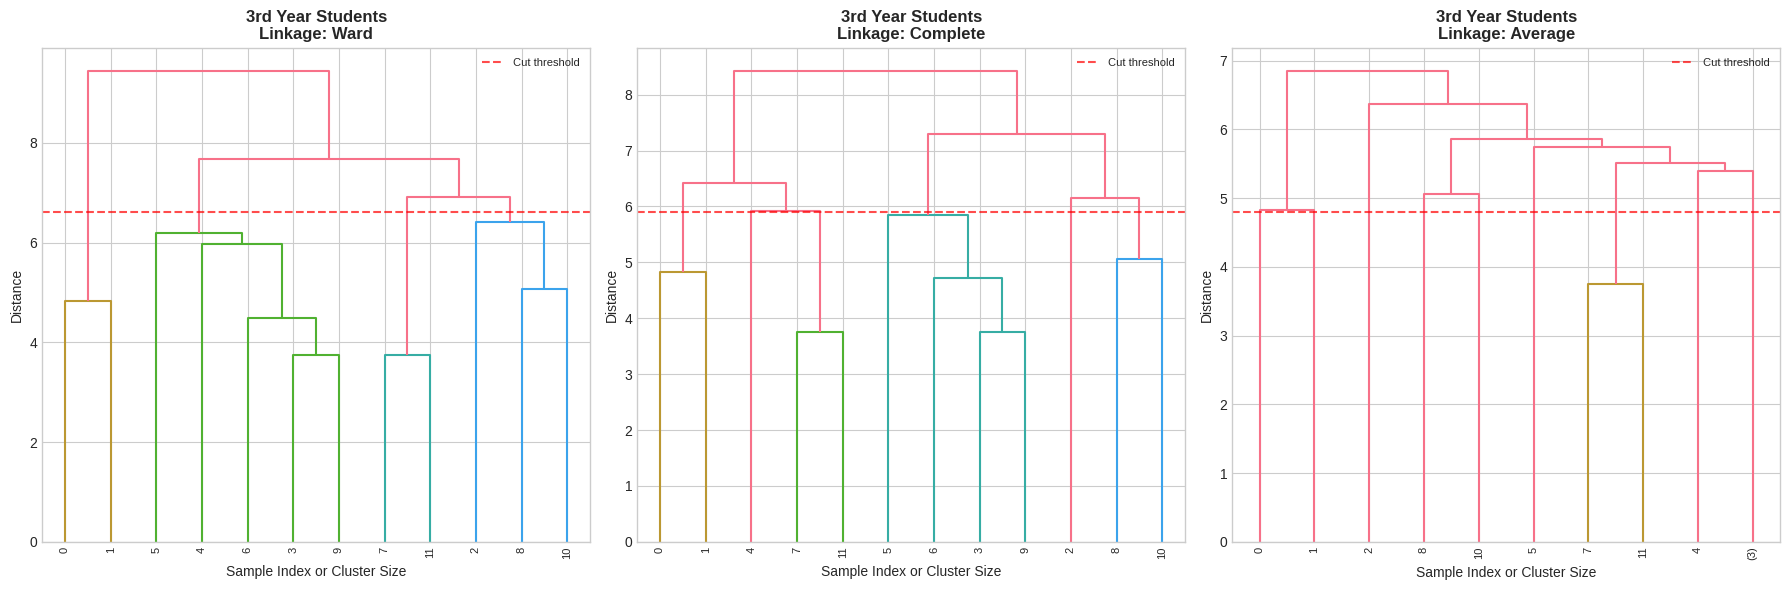

In [69]:
# 3rd Year Dendrogram Analysis
print("\n" + "-"*60)
print("3RD YEAR STUDENTS - DENDROGRAM")
print("-"*60)
linkage_3y = plot_dendrogram(X_3y_scaled, "3rd Year Students")

## 4. Agglomerative Clustering Implementation

In [70]:
# =============================================================================
# Agglomerative Clustering with Multiple Configurations
# =============================================================================

def run_agglomerative_analysis(X_scaled, n_clusters_range, linkage_methods, dataset_name):
    """
    Run Agglomerative Clustering with multiple configurations and evaluate results.
    """
    results = []
    
    print(f"\n{'='*70}")
    print(f"AGGLOMERATIVE CLUSTERING ANALYSIS: {dataset_name}")
    print(f"{'='*70}")
    print(f"\nTesting n_clusters: {n_clusters_range}")
    print(f"Testing linkage methods: {linkage_methods}")
    
    for linkage_method in linkage_methods:
        for n_clusters in n_clusters_range:
            # Run clustering
            model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
            labels = model.fit_predict(X_scaled)
            
            # Calculate metrics (only if more than 1 cluster and not all same label)
            if len(set(labels)) > 1:
                silhouette = silhouette_score(X_scaled, labels)
                calinski = calinski_harabasz_score(X_scaled, labels)
                davies = davies_bouldin_score(X_scaled, labels)
            else:
                silhouette, calinski, davies = np.nan, np.nan, np.nan
            
            results.append({
                'linkage': linkage_method,
                'n_clusters': n_clusters,
                'silhouette': silhouette,
                'calinski_harabasz': calinski,
                'davies_bouldin': davies,
                'labels': labels
            })
    
    # Display results table
    print(f"\n{'Linkage':<12} {'Clusters':<10} {'Silhouette':<12} {'CH Index':<14} {'DB Index':<12}")
    print("-" * 60)
    for r in results:
        sil_str = f"{r['silhouette']:.3f}" if not np.isnan(r['silhouette']) else "N/A"
        ch_str = f"{r['calinski_harabasz']:.1f}" if not np.isnan(r['calinski_harabasz']) else "N/A"
        db_str = f"{r['davies_bouldin']:.3f}" if not np.isnan(r['davies_bouldin']) else "N/A"
        print(f"{r['linkage']:<12} {r['n_clusters']:<10} {sil_str:<12} {ch_str:<14} {db_str:<12}")
    
    return results

# Define parameters to test
n_clusters_range = [2, 3, 4, 5, 6]
linkage_methods = ['ward', 'complete', 'average']

In [71]:
# 1st Year Clustering Analysis
results_1y = run_agglomerative_analysis(X_1y_scaled, n_clusters_range, linkage_methods, "1st Year Students")


AGGLOMERATIVE CLUSTERING ANALYSIS: 1st Year Students

Testing n_clusters: [2, 3, 4, 5, 6]
Testing linkage methods: ['ward', 'complete', 'average']

Linkage      Clusters   Silhouette   CH Index       DB Index    
------------------------------------------------------------
ward         2          0.078        18.6           3.270       
ward         3          0.072        14.5           2.949       
ward         4          0.063        13.1           2.881       
ward         5          0.055        12.4           2.780       
ward         6          0.055        11.7           2.770       
complete     2          0.174        7.7            2.526       
complete     3          0.088        14.4           2.992       
complete     4          0.088        11.2           2.503       
complete     5          0.076        10.5           2.686       
complete     6          0.074        9.5            2.372       
average      2          0.210        3.2            1.359       
average   

In [72]:
# 2nd Year Clustering Analysis
results_2y = run_agglomerative_analysis(X_2y_scaled, n_clusters_range, linkage_methods, "2nd Year Students")


AGGLOMERATIVE CLUSTERING ANALYSIS: 2nd Year Students

Testing n_clusters: [2, 3, 4, 5, 6]
Testing linkage methods: ['ward', 'complete', 'average']

Linkage      Clusters   Silhouette   CH Index       DB Index    
------------------------------------------------------------
ward         2          0.107        9.0            2.556       
ward         3          0.058        8.5            2.741       
ward         4          0.068        8.3            2.579       
ward         5          0.072        7.9            2.482       
ward         6          0.080        7.5            2.144       
complete     2          0.129        8.1            2.323       
complete     3          0.088        6.0            2.114       
complete     4          0.066        7.0            2.593       
complete     5          0.067        6.5            2.326       
complete     6          0.080        6.7            2.172       
average      2          0.289        5.5            0.856       
average   

In [73]:
# 3rd Year Clustering Analysis
results_3y = run_agglomerative_analysis(X_3y_scaled, n_clusters_range, linkage_methods, "3rd Year Students")


AGGLOMERATIVE CLUSTERING ANALYSIS: 3rd Year Students

Testing n_clusters: [2, 3, 4, 5, 6]
Testing linkage methods: ['ward', 'complete', 'average']

Linkage      Clusters   Silhouette   CH Index       DB Index    
------------------------------------------------------------
ward         2          0.187        2.8            1.205       
ward         3          0.120        2.6            1.703       
ward         4          0.116        2.5            1.369       
ward         5          0.124        2.4            1.104       
ward         6          0.129        2.5            0.939       
complete     2          0.101        2.4            1.979       
complete     3          0.105        2.3            1.596       
complete     4          0.111        2.5            1.406       
complete     5          0.119        2.4            1.195       
complete     6          0.120        2.5            0.942       
average      2          0.187        2.8            1.205       
average   

## 5. Optimal Configuration Selection

In [74]:
# =============================================================================
# Select Optimal Configuration
# =============================================================================

def select_optimal_config(results, dataset_name):
    """
    Select optimal clustering configuration based on:
    1. Best silhouette score (higher is better)
    2. Reasonable number of clusters (2-5 preferred)
    """
    print(f"\n{'='*60}")
    print(f"OPTIMAL CONFIGURATION: {dataset_name}")
    print(f"{'='*60}")
    
    # Filter valid results
    valid_results = [r for r in results if not np.isnan(r['silhouette'])]
    
    if not valid_results:
        print("\nNo valid clustering configurations found.")
        return None, None
    
    # Score based on silhouette (primary) and prefer fewer clusters
    for r in valid_results:
        cluster_penalty = 0.01 * (r['n_clusters'] - 2) if r['n_clusters'] > 3 else 0
        r['score'] = r['silhouette'] - cluster_penalty
    
    # Select best
    best = max(valid_results, key=lambda x: x['score'])
    
    print(f"\nSelected Configuration:")
    print(f"   - Linkage method: {best['linkage']}")
    print(f"   - Number of clusters: {best['n_clusters']}")
    print(f"   - Silhouette Score: {best['silhouette']:.3f}")
    print(f"   - Calinski-Harabasz Index: {best['calinski_harabasz']:.1f}")
    print(f"   - Davies-Bouldin Index: {best['davies_bouldin']:.3f}")
    
    return best['linkage'], best

# Select optimal for each dataset
linkage_1y_opt, best_1y = select_optimal_config(results_1y, "1st Year Students")
linkage_2y_opt, best_2y = select_optimal_config(results_2y, "2nd Year Students")
linkage_3y_opt, best_3y = select_optimal_config(results_3y, "3rd Year Students")


OPTIMAL CONFIGURATION: 1st Year Students

Selected Configuration:
   - Linkage method: average
   - Number of clusters: 2
   - Silhouette Score: 0.210
   - Calinski-Harabasz Index: 3.2
   - Davies-Bouldin Index: 1.359

OPTIMAL CONFIGURATION: 2nd Year Students

Selected Configuration:
   - Linkage method: average
   - Number of clusters: 2
   - Silhouette Score: 0.289
   - Calinski-Harabasz Index: 5.5
   - Davies-Bouldin Index: 0.856

OPTIMAL CONFIGURATION: 3rd Year Students

Selected Configuration:
   - Linkage method: ward
   - Number of clusters: 2
   - Silhouette Score: 0.187
   - Calinski-Harabasz Index: 2.8
   - Davies-Bouldin Index: 1.205


## 6. Visualization of Clustering Results

In [75]:
# =============================================================================
# Visualize Clustering Results using PCA
# =============================================================================

def visualize_clustering_results(X_scaled, labels, linkage_method, n_clusters, dataset_name):
    """
    Visualize clustering results using PCA for dimensionality reduction.
    """
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Cluster visualization
    unique_labels = sorted(set(labels))
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        class_mask = labels == k
        axes[0].scatter(X_pca[class_mask, 0], X_pca[class_mask, 1],
                       c=[col], marker='o', s=50, alpha=0.7, 
                       label=f'Cluster {k} (n={sum(class_mask)})',
                       edgecolors='black', linewidth=0.5)
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[0].set_title(f'{dataset_name}\nAgglomerative Clustering (linkage={linkage_method}, k={n_clusters})', 
                     fontsize=12, fontweight='bold')
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Cluster size distribution
    cluster_counts = pd.Series(labels).value_counts().sort_index()
    colors_bar = [plt.cm.Set1(i/len(unique_labels)) for i in range(len(unique_labels))]
    
    bars = axes[1].bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, edgecolor='black')
    axes[1].set_xticks(range(len(cluster_counts)))
    axes[1].set_xticklabels([f'Cluster {i}' for i in cluster_counts.index], rotation=45, ha='right')
    axes[1].set_xlabel('Cluster', fontsize=11)
    axes[1].set_ylabel('Number of Points', fontsize=11)
    axes[1].set_title(f'{dataset_name}\nCluster Size Distribution', fontsize=12, fontweight='bold')
    
    for bar, count in zip(bars, cluster_counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom', fontsize=10)
    
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return X_pca, pca

print("\n" + "="*80)
print("CLUSTERING VISUALIZATION")
print("="*80)


CLUSTERING VISUALIZATION



------------------------------------------------------------
1ST YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


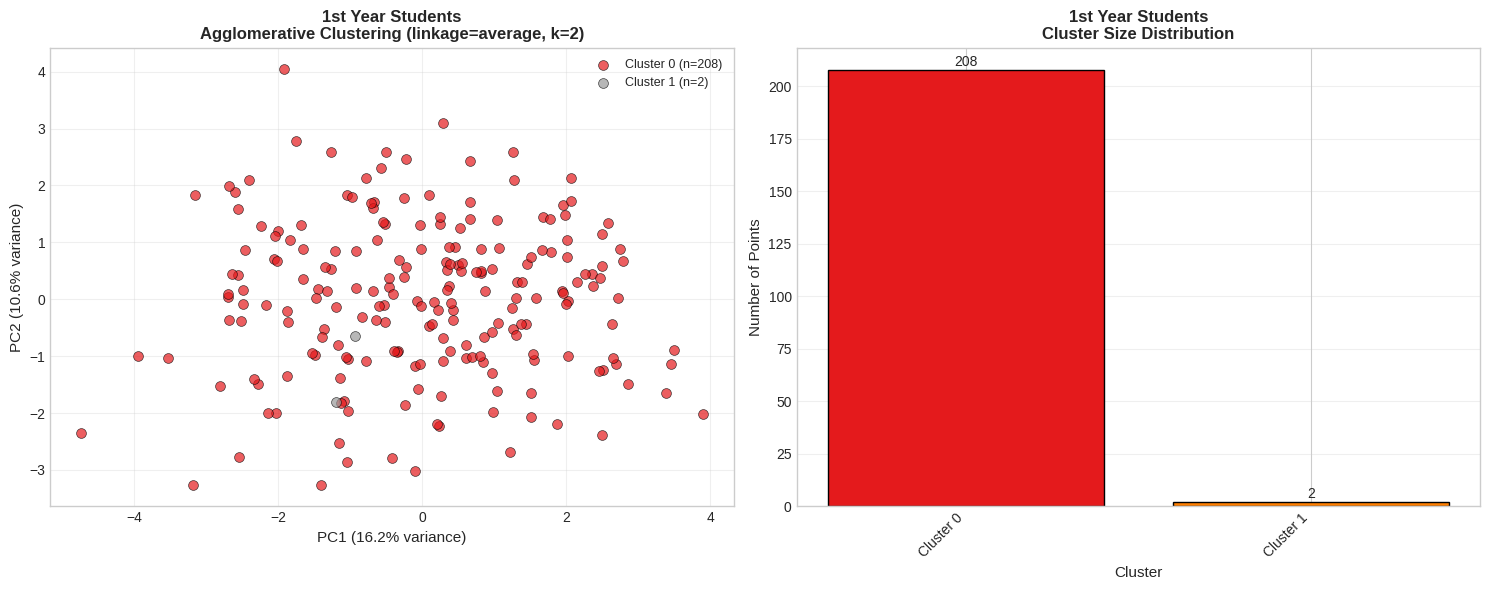

In [76]:
# Visualize 1st Year Results
if best_1y is not None:
    print("\n" + "-"*60)
    print("1ST YEAR STUDENTS - VISUALIZATION")
    print("-"*60)
    X_pca_1y, pca_1y = visualize_clustering_results(X_1y_scaled, best_1y['labels'], 
                                                     best_1y['linkage'], best_1y['n_clusters'], 
                                                     "1st Year Students")


------------------------------------------------------------
2ND YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


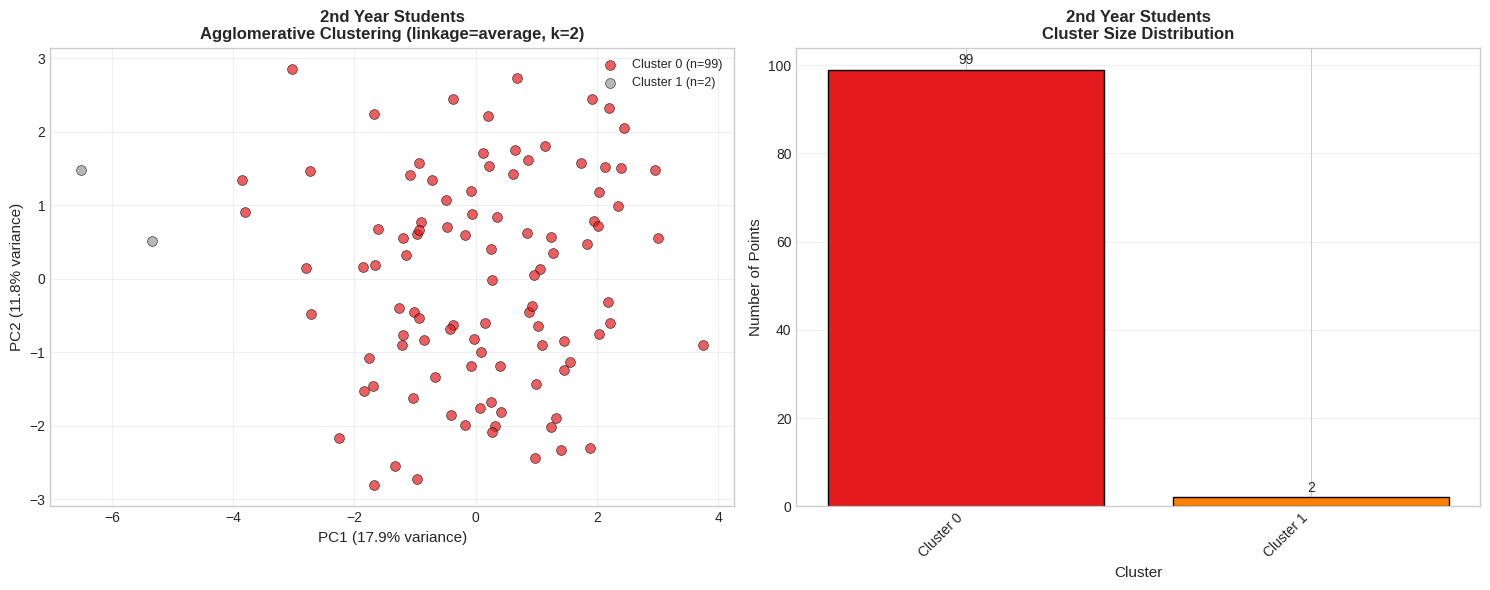

In [77]:
# Visualize 2nd Year Results
if best_2y is not None:
    print("\n" + "-"*60)
    print("2ND YEAR STUDENTS - VISUALIZATION")
    print("-"*60)
    X_pca_2y, pca_2y = visualize_clustering_results(X_2y_scaled, best_2y['labels'], 
                                                     best_2y['linkage'], best_2y['n_clusters'], 
                                                     "2nd Year Students")


------------------------------------------------------------
3RD YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


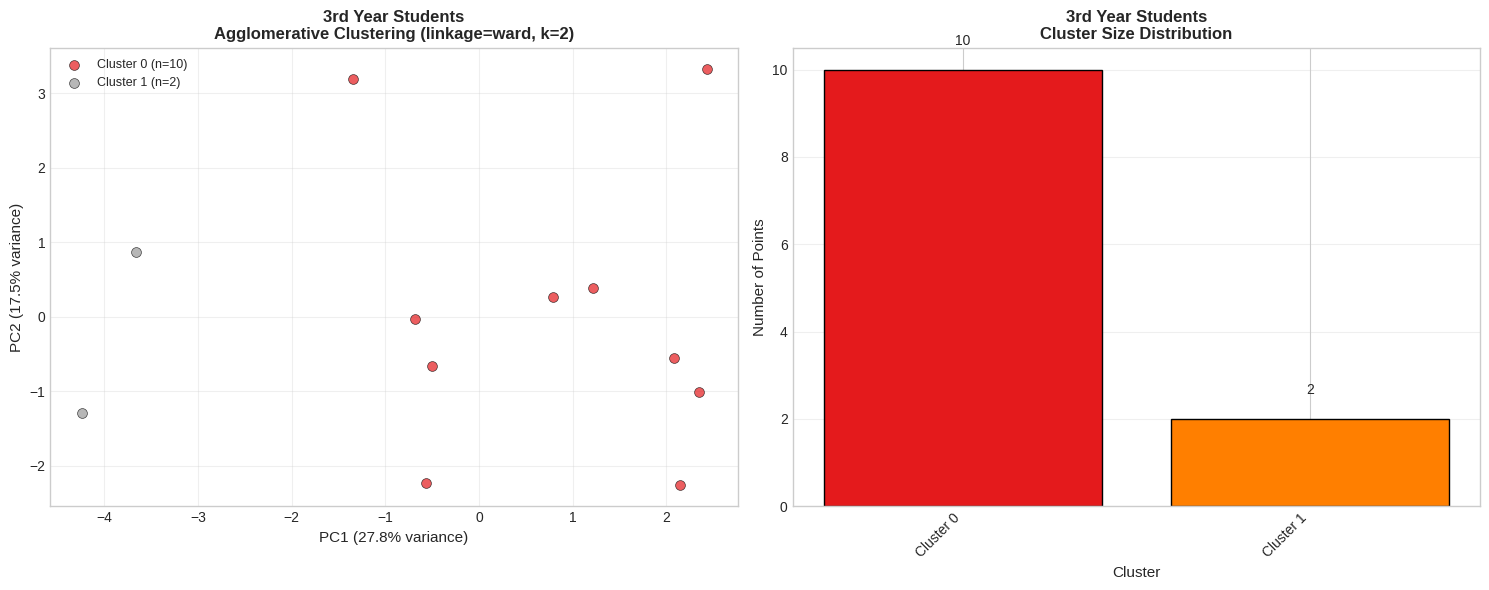

In [78]:
# Visualize 3rd Year Results
if best_3y is not None:
    print("\n" + "-"*60)
    print("3RD YEAR STUDENTS - VISUALIZATION")
    print("-"*60)
    X_pca_3y, pca_3y = visualize_clustering_results(X_3y_scaled, best_3y['labels'], 
                                                     best_3y['linkage'], best_3y['n_clusters'], 
                                                     "3rd Year Students")

## 7. Cluster Profiling and Interpretation

In [79]:
# =============================================================================
# Cluster Profiling
# =============================================================================

def profile_clusters(df, features, labels, dataset_name):
    """
    Create detailed profiles of each cluster.
    """
    print(f"\n{'='*70}")
    print(f"CLUSTER PROFILING: {dataset_name}")
    print(f"{'='*70}")
    
    if labels is None:
        print("\nNo clustering results available.")
        return None
    
    df_analysis = df[features].copy()
    df_analysis['Cluster'] = labels
    
    n_clusters = len(set(labels))
    print(f"\nNumber of clusters: {n_clusters}")
    
    # Cluster sizes
    print(f"\nCluster Sizes:")
    for i in range(n_clusters):
        print(f"   Cluster {i}: {sum(labels == i)} samples")
    
    # Cluster means
    cluster_profiles = df_analysis.groupby('Cluster').mean()
    print(f"\nCluster Centers (Mean values):")
    display(cluster_profiles.round(2))
    
    # Key distinguishing features
    print(f"\nKey Distinguishing Features by Cluster:")
    overall_mean = df_analysis[features].mean()
    
    for cluster in range(n_clusters):
        print(f"\n  Cluster {cluster}:")
        cluster_mean = cluster_profiles.loc[cluster]
        
        diff = (cluster_mean - overall_mean).abs().sort_values(ascending=False)
        top_features = diff.head(5)
        
        for feat in top_features.index:
            direction = "Higher" if cluster_mean[feat] > overall_mean[feat] else "Lower"
            print(f"    - {feat}: {direction} than average ({cluster_mean[feat]:.2f} vs {overall_mean[feat]:.2f})")
    
    return cluster_profiles

# Profile clusters for each year
if best_1y is not None:
    profile_1y = profile_clusters(data_1y, common_features, best_1y['labels'], "1st Year Students")


CLUSTER PROFILING: 1st Year Students

Number of clusters: 2

Cluster Sizes:
   Cluster 0: 208 samples
   Cluster 1: 2 samples

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
0,0.45,0.57,1.18,2.2,0.26,25.93,20.11,0.38,7.23,6.53,6.35,6.55,3.47,1.28,3.0,2.45,0.56
1,0.50,1.50,0.00,2.0,2.00,11.50,24.00,0.00,9.00,4.00,5.00,6.50,1.00,2.00,3.0,3.00,1.00



Key Distinguishing Features by Cluster:

  Cluster 0:
    - learning_methods: Higher than average (25.93 vs 25.80)
    - study_resources: Lower than average (20.11 vs 20.15)
    - programming_level: Higher than average (6.53 vs 6.50)
    - motivation_level: Higher than average (3.47 vs 3.45)
    - english_level: Lower than average (7.23 vs 7.25)

  Cluster 1:
    - learning_methods: Lower than average (11.50 vs 25.80)
    - study_resources: Higher than average (24.00 vs 20.15)
    - programming_level: Lower than average (4.00 vs 6.50)
    - motivation_level: Lower than average (1.00 vs 3.45)
    - english_level: Higher than average (9.00 vs 7.25)


In [80]:
# Profile 2nd Year clusters
if best_2y is not None:
    profile_2y = profile_clusters(data_2y, common_features, best_2y['labels'], "2nd Year Students")


CLUSTER PROFILING: 2nd Year Students

Number of clusters: 2

Cluster Sizes:
   Cluster 0: 99 samples
   Cluster 1: 2 samples

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
0,0.43,0.47,0.81,1.4,0.32,22.39,17.24,0.34,7.69,7.08,6.99,6.9,3.38,0.29,3.21,2.6,0.63
1,0.00,2.00,0.50,2.0,0.00,31.00,9.00,0.50,6.50,2.00,4.00,2.0,2.00,0.00,1.00,2.0,0.50



Key Distinguishing Features by Cluster:

  Cluster 0:
    - learning_methods: Lower than average (22.39 vs 22.56)
    - study_resources: Higher than average (17.24 vs 17.08)
    - programming_level: Higher than average (7.08 vs 6.98)
    - mathematics_level: Higher than average (6.90 vs 6.80)
    - computer_science_level: Higher than average (6.99 vs 6.93)

  Cluster 1:
    - learning_methods: Higher than average (31.00 vs 22.56)
    - study_resources: Lower than average (9.00 vs 17.08)
    - programming_level: Lower than average (2.00 vs 6.98)
    - mathematics_level: Lower than average (2.00 vs 6.80)
    - computer_science_level: Lower than average (4.00 vs 6.93)


In [81]:
# Profile 3rd Year clusters
if best_3y is not None:
    profile_3y = profile_clusters(data_3y, common_features, best_3y['labels'], "3rd Year Students")


CLUSTER PROFILING: 3rd Year Students

Number of clusters: 2

Cluster Sizes:
   Cluster 0: 10 samples
   Cluster 1: 2 samples

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
0,0.3,0.3,0.7,1.5,0.2,4.9,3.9,0.5,8.1,7.5,7.5,7.4,3.1,0.3,3.1,2.6,0.6
1,0.5,1.0,0.0,2.0,0.0,7.5,5.5,1.0,7.0,3.5,5.0,3.5,2.0,0.5,1.5,1.5,0.5



Key Distinguishing Features by Cluster:

  Cluster 0:
    - programming_level: Higher than average (7.50 vs 6.83)
    - mathematics_level: Higher than average (7.40 vs 6.75)
    - learning_methods: Lower than average (4.90 vs 5.33)
    - computer_science_level: Higher than average (7.50 vs 7.08)
    - study_resources: Lower than average (3.90 vs 4.17)

  Cluster 1:
    - programming_level: Lower than average (3.50 vs 6.83)
    - mathematics_level: Lower than average (3.50 vs 6.75)
    - learning_methods: Higher than average (7.50 vs 5.33)
    - computer_science_level: Lower than average (5.00 vs 7.08)
    - stress_management: Lower than average (1.50 vs 2.83)


## 8. Suitability Assessment

In [82]:
# =============================================================================
# Suitability Assessment
# =============================================================================

def assess_hac_suitability(results, best_result, dataset_name, n_samples):
    """
    Assess whether Hierarchical Agglomerative Clustering is suitable for the dataset.
    
    Criteria:
    1. Good silhouette score (> 0.25 acceptable, > 0.5 good)
    2. Reasonable cluster sizes (not heavily imbalanced)
    3. Adequate sample size
    4. Consistent results across different linkage methods
    """
    print(f"\n{'='*70}")
    print(f"HAC SUITABILITY ASSESSMENT: {dataset_name}")
    print(f"{'='*70}")
    
    assessment = {
        'dataset': dataset_name,
        'n_samples': n_samples,
        'issues': [],
        'positives': [],
        'recommendation': ''
    }
    
    if best_result is None:
        print("\nNo valid clustering results to assess.")
        assessment['issues'].append("No valid clustering results")
        assessment['suitability'] = "NOT SUITABLE"
        return assessment
    
    silhouette = best_result['silhouette']
    n_clusters = best_result['n_clusters']
    labels = best_result['labels']
    linkage_method = best_result['linkage']
    
    print(f"\nDataset Statistics:")
    print(f"   - Sample size: {n_samples}")
    print(f"   - Optimal clusters: {n_clusters}")
    print(f"   - Optimal linkage: {linkage_method}")
    print(f"   - Silhouette score: {silhouette:.3f}")
    
    print(f"\nAssessment Criteria:")
    
    # 1. Silhouette score
    print(f"\n   1. Clustering Quality (Silhouette Score):")
    if silhouette >= 0.5:
        print(f"      PASS: Good silhouette score ({silhouette:.3f})")
        assessment['positives'].append(f"Good cluster quality (silhouette={silhouette:.3f})")
    elif silhouette >= 0.25:
        print(f"      PASS: Acceptable silhouette score ({silhouette:.3f})")
        assessment['positives'].append(f"Acceptable cluster quality (silhouette={silhouette:.3f})")
    elif silhouette > 0:
        print(f"      WARNING: Low silhouette score ({silhouette:.3f})")
        assessment['issues'].append(f"Weak cluster structure (silhouette={silhouette:.3f})")
    else:
        print(f"      FAIL: Negative silhouette ({silhouette:.3f})")
        assessment['issues'].append(f"Poor cluster separation (silhouette={silhouette:.3f})")
    
    # 2. Sample size
    print(f"\n   2. Sample Size Adequacy:")
    if n_samples >= 100:
        print(f"      PASS: Adequate sample size ({n_samples})")
        assessment['positives'].append(f"Adequate sample size ({n_samples})")
    elif n_samples >= 50:
        print(f"      WARNING: Limited sample size ({n_samples})")
        assessment['issues'].append(f"Limited sample size ({n_samples})")
    else:
        print(f"      FAIL: Small sample size ({n_samples})")
        assessment['issues'].append(f"Small sample size ({n_samples})")
    
    # 3. Cluster balance
    print(f"\n   3. Cluster Balance:")
    cluster_sizes = [sum(labels == i) for i in range(n_clusters)]
    size_ratio = max(cluster_sizes) / max(min(cluster_sizes), 1)
    if size_ratio <= 3:
        print(f"      PASS: Well balanced clusters (ratio {size_ratio:.1f}:1)")
        assessment['positives'].append("Balanced cluster sizes")
    elif size_ratio <= 10:
        print(f"      WARNING: Moderately imbalanced clusters (ratio {size_ratio:.1f}:1)")
        assessment['issues'].append("Moderately imbalanced clusters")
    else:
        print(f"      WARNING: Highly imbalanced clusters (ratio {size_ratio:.1f}:1)")
        assessment['issues'].append("Highly imbalanced clusters")
    
    # 4. Consistency across linkage methods
    print(f"\n   4. Consistency Across Linkage Methods:")
    valid_results = [r for r in results if not np.isnan(r['silhouette']) and r['n_clusters'] == n_clusters]
    if len(valid_results) >= 2:
        silhouettes = [r['silhouette'] for r in valid_results]
        sil_std = np.std(silhouettes)
        if sil_std < 0.05:
            print(f"      PASS: Consistent results across methods (std={sil_std:.3f})")
            assessment['positives'].append("Consistent across linkage methods")
        else:
            print(f"      WARNING: Variable results across methods (std={sil_std:.3f})")
            assessment['issues'].append("Results vary with linkage method")
    
    # Overall verdict
    print(f"\n" + "="*70)
    print("OVERALL RECOMMENDATION")
    print("="*70)
    
    n_issues = len(assessment['issues'])
    n_positives = len(assessment['positives'])
    
    if silhouette >= 0.25 and n_issues <= 1:
        suitability = "SUITABLE"
        assessment['recommendation'] = "HAC is appropriate for this dataset"
        print(f"\nVERDICT: HAC is SUITABLE for {dataset_name}")
    elif silhouette >= 0.15 and n_issues <= 2:
        suitability = "MARGINALLY SUITABLE"
        assessment['recommendation'] = "HAC shows acceptable effectiveness"
        print(f"\nVERDICT: HAC is MARGINALLY SUITABLE for {dataset_name}")
    else:
        suitability = "NOT SUITABLE"
        assessment['recommendation'] = "HAC is NOT recommended for this dataset"
        print(f"\nVERDICT: HAC is NOT SUITABLE for {dataset_name}")
    
    if assessment['issues']:
        print(f"\nIssues:")
        for issue in assessment['issues']:
            print(f"   - {issue}")
    
    if assessment['positives']:
        print(f"\nPositives:")
        for positive in assessment['positives']:
            print(f"   - {positive}")
    
    assessment['suitability'] = suitability
    return assessment

# Assess suitability for each dataset
assessment_1y = assess_hac_suitability(results_1y, best_1y, "1st Year Students", len(data_1y))


HAC SUITABILITY ASSESSMENT: 1st Year Students

Dataset Statistics:
   - Sample size: 210
   - Optimal clusters: 2
   - Optimal linkage: average
   - Silhouette score: 0.210

Assessment Criteria:

   1. Clustering Quality (Silhouette Score):

   2. Sample Size Adequacy:
      PASS: Adequate sample size (210)

   3. Cluster Balance:

   4. Consistency Across Linkage Methods:

OVERALL RECOMMENDATION

VERDICT: HAC is NOT SUITABLE for 1st Year Students

Issues:
   - Weak cluster structure (silhouette=0.210)
   - Highly imbalanced clusters
   - Results vary with linkage method

Positives:
   - Adequate sample size (210)


In [83]:
# Assess 2nd Year
assessment_2y = assess_hac_suitability(results_2y, best_2y, "2nd Year Students", len(data_2y))


HAC SUITABILITY ASSESSMENT: 2nd Year Students

Dataset Statistics:
   - Sample size: 101
   - Optimal clusters: 2
   - Optimal linkage: average
   - Silhouette score: 0.289

Assessment Criteria:

   1. Clustering Quality (Silhouette Score):
      PASS: Acceptable silhouette score (0.289)

   2. Sample Size Adequacy:
      PASS: Adequate sample size (101)

   3. Cluster Balance:

   4. Consistency Across Linkage Methods:

OVERALL RECOMMENDATION

VERDICT: HAC is MARGINALLY SUITABLE for 2nd Year Students

Issues:
   - Highly imbalanced clusters
   - Results vary with linkage method

Positives:
   - Acceptable cluster quality (silhouette=0.289)
   - Adequate sample size (101)


In [84]:
# Assess 3rd Year
assessment_3y = assess_hac_suitability(results_3y, best_3y, "3rd Year Students", len(data_3y))


HAC SUITABILITY ASSESSMENT: 3rd Year Students

Dataset Statistics:
   - Sample size: 12
   - Optimal clusters: 2
   - Optimal linkage: ward
   - Silhouette score: 0.187

Assessment Criteria:

   1. Clustering Quality (Silhouette Score):

   2. Sample Size Adequacy:
      FAIL: Small sample size (12)

   3. Cluster Balance:

   4. Consistency Across Linkage Methods:
      PASS: Consistent results across methods (std=0.041)

OVERALL RECOMMENDATION

VERDICT: HAC is NOT SUITABLE for 3rd Year Students

Issues:
   - Weak cluster structure (silhouette=0.187)
   - Small sample size (12)
   - Moderately imbalanced clusters

Positives:
   - Consistent across linkage methods


## 9. Summary and Conclusions

In [85]:
# =============================================================================
# Final Summary Report
# =============================================================================

print("\n" + "="*80)
print("HIERARCHICAL AGGLOMERATIVE CLUSTERING - FINAL SUMMARY REPORT")
print("="*80)

print("\n" + "-"*80)
print("OPTIMAL CONFIGURATION SUMMARY")
print("-"*80)

print(f"\n{'Dataset':<20} {'Linkage':<12} {'Clusters':<10} {'Silhouette':<12} {'CH Index':<14} {'DB Index':<12}")
print("-" * 80)

for name, best in [
    ("1st Year", best_1y),
    ("2nd Year", best_2y),
    ("3rd Year", best_3y)
]:
    if best is not None:
        sil_str = f"{best['silhouette']:.3f}"
        ch_str = f"{best['calinski_harabasz']:.1f}"
        db_str = f"{best['davies_bouldin']:.3f}"
        print(f"{name:<20} {best['linkage']:<12} {best['n_clusters']:<10} {sil_str:<12} {ch_str:<14} {db_str:<12}")
    else:
        print(f"{name:<20} {'N/A':<12} {'N/A':<10} {'N/A':<12} {'N/A':<14} {'N/A':<12}")

print("\n" + "-"*80)
print("SUITABILITY SUMMARY")
print("-"*80)

for name, assessment in [
    ("1st Year Students", assessment_1y),
    ("2nd Year Students", assessment_2y),
    ("3rd Year Students", assessment_3y)
]:
    status = "[+]" if assessment['suitability'] == "SUITABLE" else "[~]" if assessment['suitability'] == "MARGINALLY SUITABLE" else "[-]"
    print(f"\n{status} {name}: {assessment['suitability']}")
    print(f"    {assessment['recommendation']}")

print("\n" + "-"*80)
print("INTERPRETATION")
print("-"*80)
print("""
Linkage Method Selection:
   - Ward: Minimizes within-cluster variance, tends to produce compact clusters
   - Complete: Uses maximum distance, produces more compact clusters
   - Average: Uses mean distance, balance between single and complete

Metric Interpretation:
   - Silhouette Score: Measures cluster cohesion and separation
     > 0.5: Strong structure | 0.25-0.5: Reasonable structure | < 0.25: Weak structure
   - Calinski-Harabasz Index: Higher values indicate better defined clusters
   - Davies-Bouldin Index: Lower values indicate better clustering (less similarity between clusters)

Key Observations:
   - HAC does not require specifying density parameters like DBSCAN
   - Works well with smaller datasets where hierarchy exploration is valuable
   - Ward linkage typically performs best with Euclidean distance on standardized data
   - Results are deterministic (no random initialization)
""")


HIERARCHICAL AGGLOMERATIVE CLUSTERING - FINAL SUMMARY REPORT

--------------------------------------------------------------------------------
OPTIMAL CONFIGURATION SUMMARY
--------------------------------------------------------------------------------

Dataset              Linkage      Clusters   Silhouette   CH Index       DB Index    
--------------------------------------------------------------------------------
1st Year             average      2          0.210        3.2            1.359       
2nd Year             average      2          0.289        5.5            0.856       
3rd Year             ward         2          0.187        2.8            1.205       

--------------------------------------------------------------------------------
SUITABILITY SUMMARY
--------------------------------------------------------------------------------

[-] 1st Year Students: NOT SUITABLE
    HAC is NOT recommended for this dataset

[~] 2nd Year Students: MARGINALLY SUITABLE
    HAC sho

## 10. Comparison with DBSCAN

In [86]:
# =============================================================================
# Comparison Summary: HAC vs DBSCAN
# =============================================================================

print("\n" + "="*80)
print("HAC vs DBSCAN COMPARISON")
print("="*80)

print("""
Comparison of Hierarchical Agglomerative Clustering vs DBSCAN for this dataset:

| Criterion                    | HAC                          | DBSCAN                       |
|------------------------------|------------------------------|------------------------------|
| Cluster Shape Assumption     | Tends toward spherical       | Arbitrary shapes             |
| Number of Clusters           | Must be specified            | Automatically determined     |
| Handles Noise/Outliers       | No (assigns all points)      | Yes (marks as noise)         |
| Scalability                  | O(n^2) - O(n^3)              | O(n log n) with spatial index|
| Deterministic                | Yes                          | Yes                          |
| Parameter Sensitivity        | Less sensitive               | More sensitive (eps, min_samples)|

Recommendation for this Dataset:
""")

# Provide specific recommendation based on results
for name, assessment_hac in [
    ("1st Year", assessment_1y),
    ("2nd Year", assessment_2y),
    ("3rd Year", assessment_3y)
]:
    print(f"\n{name}:")
    if assessment_hac['suitability'] == "SUITABLE":
        print(f"   HAC is recommended - produces well-defined clusters with good separation.")
    elif assessment_hac['suitability'] == "MARGINALLY SUITABLE":
        print(f"   HAC shows acceptable results - consider comparing with K-Means for validation.")
    else:
        print(f"   Neither HAC nor DBSCAN optimal - consider K-Means or GMM as alternatives.")

print("\n" + "="*80)
print("END OF HIERARCHICAL AGGLOMERATIVE CLUSTERING ANALYSIS")
print("="*80)


HAC vs DBSCAN COMPARISON

Comparison of Hierarchical Agglomerative Clustering vs DBSCAN for this dataset:

| Criterion                    | HAC                          | DBSCAN                       |
|------------------------------|------------------------------|------------------------------|
| Cluster Shape Assumption     | Tends toward spherical       | Arbitrary shapes             |
| Number of Clusters           | Must be specified            | Automatically determined     |
| Handles Noise/Outliers       | No (assigns all points)      | Yes (marks as noise)         |
| Scalability                  | O(n^2) - O(n^3)              | O(n log n) with spatial index|
| Deterministic                | Yes                          | Yes                          |
| Parameter Sensitivity        | Less sensitive               | More sensitive (eps, min_samples)|

Recommendation for this Dataset:


1st Year:
   Neither HAC nor DBSCAN optimal - consider K-Means or GMM as alternatives.

2nd 